<a href="https://colab.research.google.com/github/sss-blisp/research/blob/NN/NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

In [ ]:
test_df = pd.read_csv('/content/drive/My Drive/卒業論文/データ/post/test.csv')
train_df = pd.read_csv('/content/drive/My Drive/卒業論文/データ/post/train.csv')

In [ ]:
df_x = train_df[
    [
     'AU01_r','AU02_r','AU04_r','AU05_r','AU07_r','AU09_r','AU10_r','AU12_r','AU14_r', 'AU15_r', 'AU17_r', 'AU20_r', 'AU23_r', 'AU25_r', 'AU26_r', 'AU45_r',
      'dis_right_outer', 'dis_right_inner', 'dis_left_outer', 'dis_left_inner',
      'dis_eyelids_right', 'dis_eyelids_left',
      'pose_Rx', 'pose_Ry', 'pose_Rz'
    ]
]
df_y = train_df['pain'] # ラベルエンコーディング

df = pd.concat([df_y, df_x], axis=1)

In [ ]:
from sklearn import preprocessing
ss = preprocessing.StandardScaler()

df_x1 = ss.fit_transform(df_x)
df_x = pd.DataFrame(df_x1, columns=df_x.columns)
df_x


,AU01_r,AU02_r,AU04_r,AU05_r,AU07_r,AU09_r,AU10_r,AU12_r,AU14_r,AU15_r,...,AU45_r,dis_right_outer,dis_right_inner,dis_left_outer,dis_left_inner,dis_eyelids_right,dis_eyelids_left,pose_Rx,pose_Ry,pose_Rz
0,-0.503808,-0.441191,0.150092,-0.320130,-1.791560,-0.401816,-0.520305,-0.733274,-0.845995,-0.636550,...,0.212739,-2.328676,1.544646,-1.488324,1.421501,0.445451,2.335542,-0.201758,-0.450200,-0.440312
1,-0.503808,-0.441191,0.080367,-0.320130,-1.791560,-0.401816,-0.381805,-0.714308,-0.845995,-0.636550,...,0.054430,-2.081496,3.747425,-0.856660,1.850623,0.191347,1.499746,0.010264,-0.308355,-0.440312
2,-0.013652,0.912364,0.010643,-0.320130,-1.791560,-0.274072,-0.263091,-0.657409,-0.845995,-0.058485,...,-0.103879,-2.287479,3.577981,-0.291488,2.250151,0.257226,0.774719,0.222286,-0.308355,-0.733392
3,0.108887,0.912364,-0.041650,-0.320130,-1.791560,-0.274072,-0.203734,-0.638443,-0.845995,0.134203,...,-0.352650,-1.793121,2.646036,-0.973019,1.761839,0.464273,1.217791,0.292960,-0.024665,-0.733392
4,0.170156,0.912364,-0.059081,-0.320130,-1.791560,0.109158,-0.263091,-0.638443,-0.845995,0.326892,...,-0.352650,-1.669531,2.391869,-1.654551,1.924610,0.407806,0.613602,0.292960,-0.166510,-1.026472
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11439,0.537773,-0.441191,1.256965,-0.016209,-0.519616,0.364645,0.468980,0.063307,-0.457098,-0.636550,...,0.031815,-0.392438,-0.213342,-0.657188,-0.339380,0.360749,-0.343031,0.575656,0.968249,0.732009
11440,0.231426,-0.441191,1.309258,-0.320130,-0.519616,0.620132,0.587695,0.025375,-0.436630,-0.636550,...,-0.036032,-0.845600,-0.086258,-0.341356,-0.516948,0.473684,-0.393380,0.504982,0.826404,0.732009
11441,0.108887,-0.441191,1.326689,-0.320130,-0.665577,0.236901,0.468980,0.044341,-0.477567,-0.636550,...,-0.216956,-1.030985,0.294992,-0.374601,-0.487353,0.473684,-0.332961,0.504982,0.968249,0.732009
11442,-0.013652,-0.441191,1.248249,-0.320130,-0.738557,-0.146329,0.468980,0.063307,-0.436630,-0.636550,...,-0.352650,-1.010386,-0.107439,-0.308110,-0.398570,0.464273,-0.423590,0.575656,0.826404,0.732009


In [ ]:
df_y = df['pain'] # ラベルエンコーディング
df_y = df_y.reset_index(drop=True)
# 目的変数のダミー変数化
# df_x = pd.get_dummies(df_x, drop_first=True)
df = pd.concat([df_y, df_x], axis=1)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
x = torch.tensor(df_x.values, dtype=torch.float32)
t = torch.tensor(df_y.values, dtype=torch.int64)

In [ ]:
dataset = torch.utils.data.TensorDataset(x, t)

In [ ]:
from torch.utils.data import DataLoader

# trainデータセット、valデータセット、testデータセットに格納するデータの数を計算する
n_train = int(len(dataset) * 0.8)
n_val = int(len(dataset) - n_train)

# 乱数を固定する
# colabが時間切れになり再実行しても同じ結果を得られるようにする
torch.manual_seed(0)

# 元のデータセットからそれぞれに分割する
train, val = torch.utils.data.random_split(dataset, [n_train, n_val])
print(type(train))

# datasetの大きさを表示する
print(f'datasetの個数: {len(dataset)}')
print(type(dataset))
print(type(train))

<class 'torch.utils.data.dataset.Subset'>
datasetの個数: 11444
<class 'torch.utils.data.dataset.TensorDataset'>
<class 'torch.utils.data.dataset.Subset'>


In [ ]:
# バッチサイズ(1回の学習で使用するデータ数)
batch_size = 25 #

train_loader = torch.utils.data.DataLoader(train, batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(val, batch_size)


test用

In [ ]:
df_x = test_df[
    [
     'AU01_r','AU02_r','AU04_r','AU05_r','AU07_r','AU09_r','AU10_r','AU12_r','AU14_r', 'AU15_r', 'AU17_r', 'AU20_r', 'AU23_r', 'AU25_r', 'AU26_r', 'AU45_r',
      'dis_right_outer', 'dis_right_inner', 'dis_left_outer', 'dis_left_inner',
      'dis_eyelids_right', 'dis_eyelids_left',
      'pose_Rx', 'pose_Ry', 'pose_Rz'
    ]
]
df_y = test_df['pain'] # ラベルエンコーディング

df_test = pd.concat([df_y, df_x], axis=1)

In [ ]:
from sklearn import preprocessing
ss = preprocessing.StandardScaler()

df_x1 = ss.fit_transform(df_x)
df_x_test = pd.DataFrame(df_x1, columns=df_x.columns)
df_x_test


,AU01_r,AU02_r,AU04_r,AU05_r,AU07_r,AU09_r,AU10_r,AU12_r,AU14_r,AU15_r,...,AU45_r,dis_right_outer,dis_right_inner,dis_left_outer,dis_left_inner,dis_eyelids_right,dis_eyelids_left,pose_Rx,pose_Ry,pose_Rz
0,-0.549235,-0.492852,-0.702196,-0.373832,0.684787,-0.273109,-0.116399,1.106134,2.097764,-0.206274,...,-0.440381,0.934318,0.616161,-0.788429,0.823042,-1.791563,-1.133611,1.407272,-0.769066,1.390089
1,-0.386363,0.440786,-0.702196,0.231022,0.761023,0.353799,-0.116399,0.909568,1.807141,-0.500497,...,0.225423,0.378408,0.975740,-0.714117,1.078244,-1.684474,-1.280042,1.407272,-0.926387,1.549390
2,-0.386363,0.440786,-0.702196,0.231022,0.761023,0.353799,-0.116399,0.741083,1.661829,-0.794720,...,0.521336,0.308919,1.129846,-0.565493,0.737975,-1.755867,-1.313834,1.489204,-0.926387,1.549390
3,-0.386363,0.574163,-0.702196,-0.373832,0.710199,-0.004434,-0.116399,0.656840,1.749016,-0.794720,...,0.410369,0.633200,0.950056,-0.312832,0.380692,-1.755867,-1.201194,1.489204,-0.926387,1.549390
4,-0.549235,-0.226098,-0.702196,-0.373832,0.642434,0.443357,-0.116399,0.572598,1.807141,-0.794720,...,0.188434,0.100453,1.361003,-0.327694,0.431732,-1.827259,-1.347626,1.407272,-0.926387,1.549390
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2964,-0.223490,0.840917,0.024499,0.835877,-0.899224,-0.273109,-0.116399,0.600678,-0.575971,2.588849,...,0.299401,0.725852,-0.436891,0.519464,-0.929346,0.231222,0.060368,1.079545,1.276107,-0.999428
2965,0.020819,0.840917,0.093241,0.987090,-0.882283,-0.273109,-0.116399,0.572598,-0.575971,2.147514,...,0.595314,0.818503,-0.745101,0.341115,-0.572063,0.243121,-0.052272,0.997613,1.276107,-0.999428
2966,-0.304927,0.574163,-0.004961,-0.373832,-0.966989,-0.183551,-0.116399,0.460274,-0.575971,2.588849,...,0.521336,0.424734,-0.745101,0.103316,-0.435955,0.635779,0.139215,0.997613,1.276107,-0.999428
2967,0.020819,0.307409,-0.014782,-0.373832,-0.890753,-0.183551,-0.116399,0.460274,-0.575971,2.000402,...,0.262412,0.980644,-1.053312,0.177628,-0.350888,0.623880,0.150479,0.997613,1.276107,-0.999428


In [ ]:
df_y_test = df_test['pain'] # ラベルエンコーディング
df_y_test = df_y.reset_index(drop=True)
# 目的変数のダミー変数化
# df_x = pd.get_dummies(df_x, drop_first=True)
df_test = pd.concat([df_y_test, df_x_test], axis=1)

In [ ]:
x = torch.tensor(df_x.values, dtype=torch.float32)
t = torch.tensor(df_y.values, dtype=torch.int64)

In [ ]:
dataset_test = torch.utils.data.TensorDataset(x, t)

In [ ]:
# バッチサイズ(1回の学習で使用するデータ数)
batch_size = 25 #

test_loader = torch.utils.data.DataLoader(dataset_test, batch_size)


In [ ]:
class NeuralNetwork(nn.Module): #nn.Moduleパッケージを継承した独自の派生クラス、torch.nn.Moduleクラスのサブクラス化
                                 #nn.Moduleを継承
  def __init__(self):
    super(NeuralNetwork, self).__init__()
    self.fc1 = nn.Linear(25, 10)
    self.fc2 = nn.Linear(10, 5)
    self.fc3 = nn.Linear(5, 2)

  def forward(self, x):
    x = self.fc1(x) # 入力層
    x = F.relu(x) # 活性化関数
    x = self.fc2(x) # 出力層
    x = F.relu(x)
    x = self.fc3(x)

    return x
    # return max_index.item()

In [ ]:
net = NeuralNetwork() # クラスのインスタンス化
                      # NeuralNetworkに__call__メソッドが存在していることで、インスタンスの名前で関数を呼び出せるようになる
                      # y = net(x) となる

criterion = F.cross_entropy # 正解との誤差を計算する誤差関数

optimizer = torch.optim.SGD(net.parameters(), lr=0.001) # 最適化関数(確率的勾配降下法)

In [ ]:
pip install matplotlib seaborn torch torchvision torcheval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.2/179.2 kB 4.0 MB/s eta 0:00:00


In [ ]:
import torch
from torcheval.metrics.functional.classification import binary_recall

In [ ]:
def calc_acc(data_loader):
  with torch.no_grad():
    accs = []

    for batch in data_loader:
      x, t = batch # data_loader内の一個のデータが入る
      y = net(x) # ニューラルネットワーククラスでの計算結果を格納する

      y_label = torch.argmax(y, dim=1) #dim=1で行ごとの最大値に対する要素番号を取得

      acc = torch.sum(y_label == t) * 1.0 / len(t)

      accs.append(acc)

    avg_acc = torch.tensor(accs).mean()

    # metric = MulticlassConfusionMatrix(2)
    # metric.update(x ,t)
    # metric.compute()

    return avg_acc

In [ ]:
import torch
from torcheval.metrics.functional.classification import multiclass_recall

In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
# 混同行列表示用関数

def make_cm(matrix, columns):
    # matrix numpy配列

    # columns 項目名リスト
    n = len(columns)

    # '正解データ'をn回繰り返すリスト生成
    act = ['正解データ'] * n
    pred = ['予測結果'] * n

    #データフレーム生成
    cm = pd.DataFrame(matrix,
        columns=[pred, columns], index=[act, columns])
    return cm


In [ ]:
def calc_recall(data_loader):
  with torch.no_grad():
    accs = []
    y_for_recall =[]
    t_for_recall = []

    for batch in data_loader:
      x, t = batch # data_loader内の一個のデータが入る
      y = net(x) # ニューラルネットワーククラスでの計算結果を格納する

      y_label = torch.argmax(y, dim=1) #dim=1で行ごとの最大値に対する要素番号を取得

      #-----
      y_label = y_label.tolist()
      t = t.tolist()

      y_for_recall.append(y_label)
      t_for_recall.append(t)
      #----

    # y_for_recall = [torch.tensor(lst, dtype=torch.int32) for lst in y_for_recall]

    # 最後のサブリストを削除
    y_for_recall = y_for_recall[:-1]
    t_for_recall = t_for_recall[:-1]

    y_for_recall = torch.tensor(y_for_recall)
    t_for_recall = torch.tensor(t_for_recall)

    y_for_recall = y_for_recall.view(-1)
    t_for_recall = t_for_recall.view(-1)

    matrix = confusion_matrix(t_for_recall, y_for_recall, labels=[1, 0])

    # make_cmを使った混同行列標示
    cm = make_cm(matrix, [1,0])
    # 結果の表示
    display(cm)

    recall = multiclass_recall(y_for_recall, t_for_recall)
    # print(recall)
    # print(type(y_for_recall))
    # print(y_for_recall)


    # metric = MulticlassConfusionMatrix(2)
    # metric.update(x ,t)
    # metric.compute()

    return recall

In [ ]:
# バッチごとで毎回、recallを算出
def calc_recall2(data_loader):
  with torch.no_grad():
    recalls = []
    y_for_recall =[]
    t_for_recall = []

    for batch in data_loader:
      x, t = batch # data_loader内の一個のデータが入る
      y = net(x) # ニューラルネットワーククラスでの計算結果を格納する

      y_label = torch.argmax(y, dim=1) #dim=1で行ごとの最大値に対する要素番号を取得

      recall = multiclass_recall(y_label, t)

      recalls.append(recall)
    avg_recall = torch.tensor(recalls).mean()

    return avg_recall

In [ ]:
def display_matrix(data_loader):
  with torch.no_grad():
    accs = []
    y_list =[]
    t_list = []

    for batch in data_loader:
      x, t = batch # data_loader内の一個のデータが入る
      y = net(x) # ニューラルネットワーククラスでの計算結果を格納する

      y_label = torch.argmax(y, dim=1) #dim=1で行ごとの最大値に対する要素番号を取得

      y_label = y_label.tolist()
      t = t.tolist()

      y_list.append(y_label)
      t_list.append(t)


    t_list = [item for sublist in t_list for item in sublist]
    y_list = [item for sublist in y_list for item in sublist]

    matrix = confusion_matrix(t_list, y_list, labels=[1, 0])

    # make_cmを使った混同行列標示
    cm = make_cm(matrix, [1,0])
    # 結果の表示
    display(cm)

    # y_list = torch.tensor(y_list)
    # t_list = torch.tensor(t_list)
    # recall = multiclass_recall(y_list, t_list)
    # print(recall)

In [ ]:
def calc_loss(data_loader):
  with torch.no_grad():
    losses = []
    for batch in data_loader:
      x, t = batch
      y = net(x)
      loss = criterion(y, t)
      losses.append(loss.item())

    avg_loss = torch.tensor(losses).mean()

    return avg_loss

In [ ]:
import matplotlib.pyplot as plt

max_epoch = 200

train_loss_list = []
train_acc_list = []
traiin_recall_list = []

val_acc_list = []
val_loss_list = []
val_recall_list = []

test_acc_list = []
test_loss_list = []
test_recall_list = []

size = len(test_loader.dataset)

net.train() #
for epoch in range(max_epoch): #
  acc_list = []
  loss_list = []
  recall_list = []

  # 学習用のデータセットのループ
  for batch in train_loader:
    x, t = batch
    optimizer.zero_grad() #勾配を初期化
    y = net(x) #__call__メソッド


    # 正解率の計算　正解率=accuracy
    y_label = torch.argmax(y, dim=1)
    acc = torch.sum(y_label == t) * 1.0 / len(t)
    acc_list.append(acc) # 正解率をリストに保存

    # -------
    recall = multiclass_recall(y_label, t)
    recall_list.append(recall)
    # -------
    loss = criterion(y, t) #関数呼び出し
    #print(type(loss))
    loss_list.append(loss.item()) # 誤差をリストに保存

    loss.backward() # 誤差から勾配を計算
    optimizer.step() # 勾配から重みの更新

  train_acc_list.append(sum(acc_list) / len(acc_list))
  train_loss_list.append(sum(loss_list) / len(loss_list))
  traiin_recall_list.append(sum(recall_list) / len(recall_list))

  val_acc = calc_acc(val_loader)
  val_acc_list.append(val_acc)
  val_loss = calc_loss(val_loader)
  val_loss_list.append(val_loss)

  val_recall = calc_recall2(val_loader)
  val_recall_list.append(val_recall)

  test_acc = calc_acc(test_loader)
  test_acc_list.append(test_acc)

  test_loss = calc_loss(test_loader)
  test_loss_list.append(test_loss)

  test_recall = calc_recall2(test_loader)
  test_recall_list.append(test_recall)

  # display_matrix(val_loader)


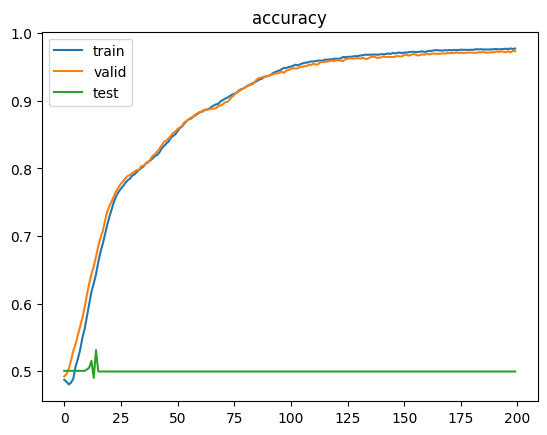

In [ ]:
# train,val,testのrecallのグラフを出力する

plt.plot(traiin_recall_list, label='train')
plt.plot(val_recall_list, label='valid')
plt.plot(test_recall_list, label='test')

# グラフにタイトルと凡例を追加
plt.title('Recall')
plt.legend()

# グラフを表示
plt.show()

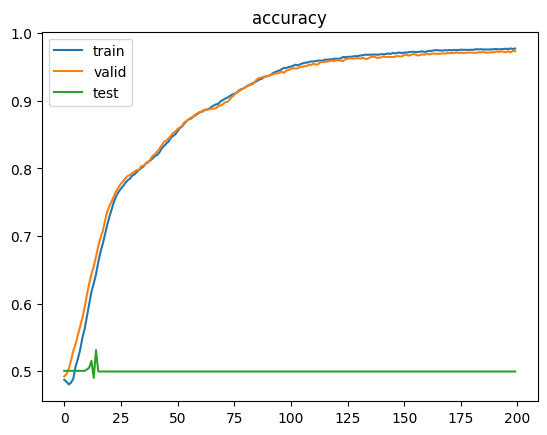

In [ ]:
# train,val,のacccuracyのグラフを出力する

plt.plot(train_acc_list, label='train')
plt.plot(val_acc_list, label='valid')
plt.plot(test_acc_list, label='test')

# グラフにタイトルと凡例を追加
plt.title('Accuracy')
plt.legend()

# グラフを表示
plt.show()

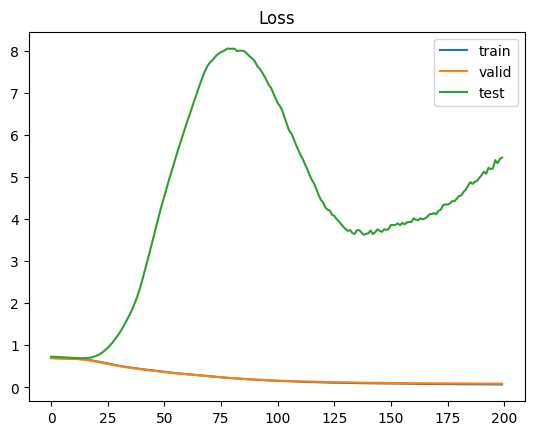

In [ ]:
# グラフを描画
plt.plot(train_loss_list, label='train')
plt.plot(val_loss_list, label='valid')
plt.plot(test_loss_list, label='test')

# グラフにタイトルと凡例を追加
plt.title('Loss')
plt.legend()

# グラフを表示
plt.show()